# Modular Restaurant Choice Data Generation with Experimental Variations

<hr style="clear:both">

This notebook extends the basic restaurant choice model to include three key experimental factors that affect choice modeling difficulty and estimation performance:

- **I{0|1}**: Data imbalance (0 = balanced, 1 = imbalanced)
- **C{0|1}**: Correlation/clones (0 = independent, 1 = correlated)  
- **M{0|1}**: Choice randomness (0 = selective, 1 = random)

## Experimental Design Factors:

<!-- ### I - Data Imbalance
- **I=0**: Balanced attribute distributions and choice probabilities
- **I=1**: (i) Skewed attributes for first 10 alternatives, (ii) Japanese cuisine dominance (high β_Japanese)

### C - Correlation/Clones  
- **C=0**: Independent alternatives maintaining IIA property
- **C=1**: Near-duplicate alternatives to test IIA violations -->

### M - Choice Randomness
- **M=0**: Selective behavior (high utility scale = clear preferences)
- **M=1**: Random behavior (low utility scale = flat/uniform choices)

**Author:** [Anne-Valérie Preto](https://people.epfl.ch/anne-valerie.preto)

<hr style="clear:both">

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(8)
random.seed(8)


# Dataset Consolidation Analysis

This section analyzes all datasets from `final_2310` to determine:
1. Which columns are shared across different configurations
2. Which values remain constant vs. vary by configuration
3. How to optimally consolidate the data

**Configuration space:**
- **J** (alternatives): 100, 200, 500
- **P** (consideration set size): 10, 20, 40
- **N** (number of observations): 10k, 20k, 50k
- **M** (choice randomness): 0 (selective), 1 (random)

In [2]:
import itertools
from pathlib import Path

# Define configurations
J_values = [100, 200, 500]
P_values = [10, 20, 40]
N_values = ['10k', '20k', '50k']
M_values = [0, 1]

base_path = Path('data/final_2310')

## Step 1: Analyze CHOICES datasets

Choices should be grouped by **N** (same number of observations).
We'll check what's shared across different J, P, M configurations.

In [3]:
# Analyze one N value first (10k) to understand structure
N = '10k'
print(f"{'='*80}")
print(f"Analyzing CHOICES with N={N}")
print(f"{'='*80}\n")

# Load a few sample datasets
sample_configs = [
    ('J100', 'P10', 'M0'),
    ('J100', 'P10', 'M1'),
    ('J100', 'P20', 'M0'),
    ('J500', 'P40', 'M1')
]

choices_samples = {}
for j, p, m in sample_configs:
    J = j[1:]
    P = p[1:]
    M = m[1:]
    filename = f"choices_J{J}_P{P}_N{N}_I0C0M{M}.csv"
    filepath = base_path / filename
    if filepath.exists():
        df = pd.read_csv(filepath)
        config_key = f"{j}_{p}_{m}"
        choices_samples[config_key] = df
        print(f"{config_key}:")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {list(df.columns)}")
        print(f"  First row:\n")
        display(df.head(1))

Analyzing CHOICES with N=10k

J100_P10_M0:
  Shape: (10000, 13)
  Columns: ['individual_id', 'user_x', 'user_y', 'gender', 'age', 'edu_secondary', 'edu_tertiary', 'income_k', 'logincome', 'risk', 'has_children', 'logit_0', 'cuisine']
  First row:



,individual_id,user_x,user_y,gender,age,edu_secondary,edu_tertiary,income_k,logincome,risk,has_children,logit_0,cuisine
0,0,54.340494,27.836939,1,56.133629,0,0,100.233771,4.607505,-1.890643,1,92,French


J100_P10_M1:
  Shape: (10000, 13)
  Columns: ['individual_id', 'user_x', 'user_y', 'gender', 'age', 'edu_secondary', 'edu_tertiary', 'income_k', 'logincome', 'risk', 'has_children', 'logit_0', 'cuisine']
  First row:



,individual_id,user_x,user_y,gender,age,edu_secondary,edu_tertiary,income_k,logincome,risk,has_children,logit_0,cuisine
0,0,54.340494,27.836939,1,56.133629,0,0,100.233771,4.607505,-1.890643,1,88,Ethiopian


J100_P20_M0:
  Shape: (10000, 13)
  Columns: ['individual_id', 'user_x', 'user_y', 'gender', 'age', 'edu_secondary', 'edu_tertiary', 'income_k', 'logincome', 'risk', 'has_children', 'logit_0', 'cuisine']
  First row:



,individual_id,user_x,user_y,gender,age,edu_secondary,edu_tertiary,income_k,logincome,risk,has_children,logit_0,cuisine
0,0,54.340494,27.836939,1,56.133629,0,0,100.233771,4.607505,-1.890643,1,84,Chinese


J500_P40_M1:
  Shape: (10000, 13)
  Columns: ['individual_id', 'user_x', 'user_y', 'gender', 'age', 'edu_secondary', 'edu_tertiary', 'income_k', 'logincome', 'risk', 'has_children', 'logit_0', 'cuisine']
  First row:



,individual_id,user_x,user_y,gender,age,edu_secondary,edu_tertiary,income_k,logincome,risk,has_children,logit_0,cuisine
0,0,54.340494,27.836939,1,56.133629,0,0,100.233771,4.607505,-1.890643,1,448,Japanese


In [4]:
# Check which columns are shared and if their values are identical
if len(choices_samples) > 1:
    all_columns = [set(df.columns) for df in choices_samples.values()]
    common_columns = set.intersection(*all_columns)
    
    print(f"\n{'='*80}")
    print(f"Common columns across all sampled configs: {len(common_columns)}")
    print(f"{'='*80}")
    print(sorted(common_columns))
    
    # Check if values are identical
    print(f"\n{'='*80}")
    print("Checking if common column VALUES are identical:")
    print(f"{'='*80}\n")
    
    first_key = list(choices_samples.keys())[0]
    first_df = choices_samples[first_key]
    
    identical_cols = []
    different_cols = []
    
    for col in sorted(common_columns):
        all_same = True
        for config_key, df in choices_samples.items():
            if config_key != first_key:
                if not first_df[col].equals(df[col]):
                    all_same = False
                    break
        
        if all_same:
            identical_cols.append(col)
        else:
            different_cols.append(col)
    
    print(f"✓ IDENTICAL across configs ({len(identical_cols)} columns):")
    for col in identical_cols:
        print(f"  - {col}")
    
    print(f"\n✗ DIFFERENT across configs ({len(different_cols)} columns):")
    for col in different_cols:
        print(f"  - {col}")
        # Show sample values from different configs
        print(f"    Sample values:")
        for config_key, df in list(choices_samples.items())[:2]:
            print(f"      {config_key}: {df[col].iloc[0]}")


Common columns across all sampled configs: 13
['age', 'cuisine', 'edu_secondary', 'edu_tertiary', 'gender', 'has_children', 'income_k', 'individual_id', 'logincome', 'logit_0', 'risk', 'user_x', 'user_y']

Checking if common column VALUES are identical:

✓ IDENTICAL across configs (11 columns):
  - age
  - edu_secondary
  - edu_tertiary
  - gender
  - has_children
  - income_k
  - individual_id
  - logincome
  - risk
  - user_x
  - user_y

✗ DIFFERENT across configs (2 columns):
  - cuisine
    Sample values:
      J100_P10_M0: French
      J100_P10_M1: Ethiopian
  - logit_0
    Sample values:
      J100_P10_M0: 92
      J100_P10_M1: 88


## Step 2: Analyze RESTAURANTS datasets

Restaurants should be grouped by **J** (same number of alternatives).
We'll check what's shared across different P, N, M configurations.

In [5]:
# Analyze one J value first (100) to understand structure
J = 100
print(f"{'='*80}")
print(f"Analyzing RESTAURANTS with J={J}")
print(f"{'='*80}\n")

# Load a few sample datasets
sample_configs = [
    ('P10', 'N10k', 'M0'),
    ('P10', 'N10k', 'M1'),
    ('P20', 'N20k', 'M0'),
    ('P40', 'N50k', 'M1')
]

restaurants_samples = {}
for p, n, m in sample_configs:
    P = p[1:]
    N = n[1:]
    M = m[1:]
    filename = f"restaurants_J{J}_P{P}_N{N}_I0C0M{M}.csv"
    filepath = base_path / filename
    if filepath.exists():
        df = pd.read_csv(filepath)
        config_key = f"{p}_{n}_{m}"
        restaurants_samples[config_key] = df
        print(f"{config_key}:")
        print(f"  Shape: {df.shape}")
        print(f"  Columns (first 15): {list(df.columns)[:15]}")
        print(f"  Total columns: {len(df.columns)}\n")

Analyzing RESTAURANTS with J=100

P10_N10k_M0:
  Shape: (100, 49)
  Columns (first 15): ['restaurant_id', 'x', 'y', 'rating', 'cost', 'cuisine', 'c_16', 'c_17', 'c_18', 'c_19', 'c_20', 'c_21', 'c_22', 'c_23', 'c_24']
  Total columns: 49

P10_N10k_M1:
  Shape: (100, 49)
  Columns (first 15): ['restaurant_id', 'x', 'y', 'rating', 'cost', 'cuisine', 'c_16', 'c_17', 'c_18', 'c_19', 'c_20', 'c_21', 'c_22', 'c_23', 'c_24']
  Total columns: 49

P20_N20k_M0:
  Shape: (100, 49)
  Columns (first 15): ['restaurant_id', 'x', 'y', 'rating', 'cost', 'cuisine', 'c_16', 'c_17', 'c_18', 'c_19', 'c_20', 'c_21', 'c_22', 'c_23', 'c_24']
  Total columns: 49

P40_N50k_M1:
  Shape: (100, 49)
  Columns (first 15): ['restaurant_id', 'x', 'y', 'rating', 'cost', 'cuisine', 'c_16', 'c_17', 'c_18', 'c_19', 'c_20', 'c_21', 'c_22', 'c_23', 'c_24']
  Total columns: 49



In [6]:
# Check which columns are shared and if their values are identical
if len(restaurants_samples) > 1:
    all_columns = [set(df.columns) for df in restaurants_samples.values()]
    common_columns = set.intersection(*all_columns)
    
    print(f"{'='*80}")
    print(f"Common columns across all sampled configs: {len(common_columns)}")
    print(f"{'='*80}")
    print(sorted(common_columns)[:20], "... (showing first 20)")
    
    # Check if values are identical for key columns
    print(f"\n{'='*80}")
    print("Checking if common column VALUES are identical:")
    print(f"{'='*80}\n")
    
    first_key = list(restaurants_samples.keys())[0]
    first_df = restaurants_samples[first_key]
    
    # Check specific columns that might be shared
    test_columns = ['restaurant_id', 'x', 'y', 'price', 'rating', 'Japanese', 'Italian', 'French']
    test_columns = [col for col in test_columns if col in common_columns]
    
    for col in test_columns:
        all_same = True
        for config_key, df in restaurants_samples.items():
            if config_key != first_key:
                # Use numpy allclose for numeric columns
                try:
                    if pd.api.types.is_numeric_dtype(first_df[col]):
                        if not np.allclose(first_df[col].fillna(0), df[col].fillna(0), rtol=1e-9, atol=1e-9):
                            all_same = False
                            break
                    else:
                        if not first_df[col].equals(df[col]):
                            all_same = False
                            break
                except:
                    if not first_df[col].equals(df[col]):
                        all_same = False
                        break
        
        status = "✓ IDENTICAL" if all_same else "✗ DIFFERENT"
        print(f"{status}: {col}")
        if not all_same:
            # Show sample values
            print(f"  Sample values from different configs:")
            for config_key, df in list(restaurants_samples.items())[:2]:
                print(f"    {config_key}: {df[col].iloc[:3].values}")

Common columns across all sampled configs: 49
['Chinese', 'Ethiopian', 'French', 'Indian', 'Japanese', 'Korean', 'Lebanese', 'Mexican', 'c_16', 'c_17', 'c_18', 'c_19', 'c_20', 'c_21', 'c_22', 'c_23', 'c_24', 'c_25', 'c_26', 'c_27'] ... (showing first 20)

Checking if common column VALUES are identical:

✓ IDENTICAL: restaurant_id
✓ IDENTICAL: x
✓ IDENTICAL: y
✓ IDENTICAL: rating
✓ IDENTICAL: Japanese
✓ IDENTICAL: French


## Step 3: Complete Analysis - All Configurations

Now let's do a comprehensive analysis across ALL configurations.

In [7]:
def analyze_choices_by_N(N_value):
    """Analyze all choices datasets with same N value"""
    print(f"\n{'='*80}")
    print(f"CHOICES with N={N_value}")
    print(f"{'='*80}\n")
    
    datasets = {}
    for J, P, M in itertools.product(J_values, P_values, M_values):
        filename = f"choices_J{J}_P{P}_N{N_value}_I0C0M{M}.csv"
        filepath = base_path / filename
        if filepath.exists():
            df = pd.read_csv(filepath)
            config_key = f"J{J}_P{P}_M{M}"
            datasets[config_key] = df
    
    print(f"Loaded {len(datasets)} datasets")
    
    if len(datasets) > 1:
        # Find common columns
        all_columns = [set(df.columns) for df in datasets.values()]
        common_columns = set.intersection(*all_columns)
        
        # Check which are identical
        first_df = list(datasets.values())[0]
        identical_cols = []
        different_cols = []
        
        for col in common_columns:
            all_same = True
            for df in list(datasets.values())[1:]:
                if not first_df[col].equals(df[col]):
                    all_same = False
                    break
            
            if all_same:
                identical_cols.append(col)
            else:
                different_cols.append(col)
        
        print(f"✓ Identical columns: {len(identical_cols)}/{len(common_columns)}")
        print(f"✗ Different columns: {len(different_cols)}/{len(common_columns)}")
        
        return {
            'N': N_value,
            'num_datasets': len(datasets),
            'datasets': datasets,
            'common_columns': common_columns,
            'identical_columns': identical_cols,
            'different_columns': different_cols
        }
    return None

# Analyze all N values
choices_analysis = {}
for N in N_values:
    result = analyze_choices_by_N(N)
    if result:
        choices_analysis[N] = result


CHOICES with N=10k

Loaded 18 datasets
✓ Identical columns: 11/13
✗ Different columns: 2/13

CHOICES with N=20k

Loaded 18 datasets
✓ Identical columns: 11/13
✗ Different columns: 2/13

CHOICES with N=50k

Loaded 18 datasets
✓ Identical columns: 11/13
✗ Different columns: 2/13

CHOICES with N=50k

Loaded 18 datasets
✓ Identical columns: 11/13
✗ Different columns: 2/13
Loaded 18 datasets
✓ Identical columns: 11/13
✗ Different columns: 2/13


In [8]:
def analyze_restaurants_by_J(J_value):
    """Analyze all restaurants datasets with same J value"""
    print(f"\n{'='*80}")
    print(f"RESTAURANTS with J={J_value}")
    print(f"{'='*80}\n")
    
    datasets = {}
    for P, N, M in itertools.product(P_values, N_values, M_values):
        filename = f"restaurants_J{J_value}_P{P}_N{N}_I0C0M{M}.csv"
        filepath = base_path / filename
        if filepath.exists():
            df = pd.read_csv(filepath)
            config_key = f"P{P}_N{N}_M{M}"
            datasets[config_key] = df
    
    print(f"Loaded {len(datasets)} datasets")
    
    if len(datasets) > 1:
        # Find common columns
        all_columns = [set(df.columns) for df in datasets.values()]
        common_columns = set.intersection(*all_columns)
        
        # Check which are identical (using numeric comparison for float columns)
        first_df = list(datasets.values())[0]
        identical_cols = []
        different_cols = []
        
        for col in common_columns:
            all_same = True
            for df in list(datasets.values())[1:]:
                try:
                    if pd.api.types.is_numeric_dtype(first_df[col]):
                        if not np.allclose(first_df[col].fillna(0), df[col].fillna(0), rtol=1e-9, atol=1e-9):
                            all_same = False
                            break
                    else:
                        if not first_df[col].equals(df[col]):
                            all_same = False
                            break
                except:
                    if not first_df[col].equals(df[col]):
                        all_same = False
                        break
            
            if all_same:
                identical_cols.append(col)
            else:
                different_cols.append(col)
        
        print(f"✓ Identical columns: {len(identical_cols)}/{len(common_columns)}")
        print(f"✗ Different columns: {len(different_cols)}/{len(common_columns)}")
        print(f"\nDifferent columns: {sorted(different_cols)[:10]} ...")
        
        return {
            'J': J_value,
            'num_datasets': len(datasets),
            'datasets': datasets,
            'common_columns': common_columns,
            'identical_columns': identical_cols,
            'different_columns': different_cols
        }
    return None

# Analyze all J values
restaurants_analysis = {}
for J in J_values:
    result = analyze_restaurants_by_J(J)
    if result:
        restaurants_analysis[J] = result


RESTAURANTS with J=100

Loaded 18 datasets
✓ Identical columns: 49/49
✗ Different columns: 0/49

Different columns: [] ...

RESTAURANTS with J=200

Loaded 18 datasets
✓ Identical columns: 49/49
✗ Different columns: 0/49

Different columns: [] ...

RESTAURANTS with J=500

Loaded 18 datasets
✓ Identical columns: 49/49
✗ Different columns: 0/49

Different columns: [] ...


## Step 7: Attribute Scale Analysis

Analyze the scale and distribution of all attributes for a specific configuration to determine if normalization is needed.

In [16]:
# ==============================================================================
# CONFIG
# ==============================================================================
CONFIG_J = 100      # Alternatives: 100, 200, 500
CONFIG_P = 10       # Parameters: 10, 20, 40
CONFIG_N = '10k'    # Observations: '10k', '20k', '50k'
CONFIG_M = 0        # Choice randomness: 0 (selective), 1 (random)
# ==============================================================================

# Load the specific configuration
filename = f"restaurants_J{CONFIG_J}_P{CONFIG_P}_N{CONFIG_N}_I0C0M{CONFIG_M}.csv"
filepath = base_path / filename

if filepath.exists():
    df_config = pd.read_csv(filepath)
    print("="*80)
    print(f"ATTRIBUTE SCALE ANALYSIS")
    print(f"Configuration: J={CONFIG_J}, P={CONFIG_P}, N={CONFIG_N}, M={CONFIG_M}")
    print("="*80)
    print(f"\nDataset shape: {df_config.shape}")
    print(f"Total columns: {len(df_config.columns)}")
else:
    print(f"❌ File not found: {filename}")
    df_config = None

ATTRIBUTE SCALE ANALYSIS
Configuration: J=100, P=10, N=10k, M=0

Dataset shape: (100, 49)
Total columns: 49


In [17]:
if df_config is not None:
    # Identify numeric columns (exclude IDs and categorical variables)
    exclude_cols = ['restaurant_id', 'Unnamed: 0']
    categorical_cols = ['Chinese', 'Japanese', 'Korean', 'Indian', 'French', 
                       'Mexican', 'Lebanese', 'Italian', 'Thai', 'American']
    
    numeric_cols = [col for col in df_config.columns 
                   if df_config[col].dtype in ['float64', 'int64'] 
                   and col not in exclude_cols 
                   and col not in categorical_cols]
    
    print(f"\n{'='*80}")
    print(f"NUMERIC ATTRIBUTES STATISTICS (excluding categorical/binary)")
    print(f"{'='*80}\n")
    
    # Compute statistics for all numeric columns
    stats_data = []
    for col in numeric_cols:
        stats_data.append({
            'Attribute': col,
            'Min': df_config[col].min(),
            'Max': df_config[col].max(),
            'Mean': df_config[col].mean(),
            'Std': df_config[col].std(),
            'Range': df_config[col].max() - df_config[col].min(),
            'Q25': df_config[col].quantile(0.25),
            'Q75': df_config[col].quantile(0.75)
        })
    
    stats_df = pd.DataFrame(stats_data)
    
    # Display with formatting
    pd.options.display.float_format = '{:.4f}'.format
    display(stats_df)
    
    print(f"\n{'='*80}")
    print(f"SCALE COMPARISON")
    print(f"{'='*80}\n")
    
    # Group by scale magnitude
    print("Attributes grouped by order of magnitude:\n")
    
    for threshold, label in [(0.01, "Very Small (<0.01)"), 
                            (0.1, "Small (0.01-0.1)"),
                            (1, "Small-Medium (0.1-1)"),
                            (10, "Medium (1-10)"), 
                            (100, "Large (10-100)"),
                            (float('inf'), "Very Large (>100)")]:
        cols_in_range = stats_df[(stats_df['Range'] < threshold) & 
                                 (stats_df['Range'] >= (0 if threshold == 0.01 else 
                                                       0.01 if threshold == 0.1 else
                                                       0.1 if threshold == 1 else
                                                       1 if threshold == 10 else
                                                       10 if threshold == 100 else 100))]
        if len(cols_in_range) > 0:
            print(f"\n{label}:")
            for _, row in cols_in_range.iterrows():
                print(f"  • {row['Attribute']:20s}: range [{row['Min']:.4f}, {row['Max']:.4f}], std={row['Std']:.4f}")
    
    print(f"\n{'='*80}")
    print(f"CATEGORICAL/BINARY ATTRIBUTES")
    print(f"{'='*80}\n")
    
    for col in categorical_cols:
        if col in df_config.columns:
            value_counts = df_config[col].value_counts()
            print(f"{col}: {dict(value_counts)}")


NUMERIC ATTRIBUTES STATISTICS (excluding categorical/binary)



,Attribute,Min,Max,Mean,Std,Range,Q25,Q75
0,x,0.7206,98.8939,48.7002,29.8991,98.1733,22.8849,77.7230
1,y,0.0744,99.7119,50.5445,26.8807,99.6375,29.8946,72.0740
2,rating,1.7653,5.0000,3.9446,0.7643,3.2347,3.5702,4.5334
3,cost,10.0000,32.0067,20.3428,4.8614,22.0067,16.2833,24.3320
4,c_16,-2.6533,2.1567,0.0115,0.9378,4.8100,-0.6526,0.6879
5,c_17,0.2925,3.7476,1.1806,0.7193,3.4551,0.7153,1.4317
6,c_18,0.0287,0.7263,0.2999,0.1657,0.6976,0.1691,0.4077
7,c_19,1.3337,4.7800,3.1129,0.6886,3.4463,2.6938,3.5170
8,c_20,-0.8509,0.8333,-0.0357,0.3004,1.6841,-0.2187,0.1939
9,c_21,-3.0000,2.8718,-0.1428,1.0471,5.8718,-0.7389,0.5044



SCALE COMPARISON

Attributes grouped by order of magnitude:


Small-Medium (0.1-1):
  • c_18                : range [0.0287, 0.7263], std=0.1657
  • c_23                : range [0.0448, 0.7021], std=0.1489
  • c_28                : range [0.0413, 0.7121], std=0.1624
  • c_33                : range [0.0361, 0.6024], std=0.1328

Medium (1-10):
  • rating              : range [1.7653, 5.0000], std=0.7643
  • c_16                : range [-2.6533, 2.1567], std=0.9378
  • c_17                : range [0.2925, 3.7476], std=0.7193
  • c_19                : range [1.3337, 4.7800], std=0.6886
  • c_20                : range [-0.8509, 0.8333], std=0.3004
  • c_21                : range [-3.0000, 2.8718], std=1.0471
  • c_22                : range [0.2077, 6.2029], std=0.8010
  • c_24                : range [1.1166, 4.8127], std=0.8037
  • c_25                : range [-0.7274, 0.7047], std=0.2851
  • c_26                : range [-2.3621, 2.3549], std=1.0259
  • c_27                : range [0.2195,

In [18]:
if df_config is not None:
    # Visual comparison of scales
    print(f"\n{'='*80}")
    print(f"NORMALIZATION RECOMMENDATION")
    print(f"{'='*80}\n")
    
    # Calculate scale ratios
    max_range = stats_df['Range'].max()
    min_range = stats_df[stats_df['Range'] > 0]['Range'].min()
    scale_ratio = max_range / min_range
    
    print(f"Largest range: {max_range:.4f} ({stats_df.loc[stats_df['Range'].idxmax(), 'Attribute']})")
    print(f"Smallest range: {min_range:.4f} ({stats_df.loc[stats_df['Range'].idxmin(), 'Attribute']})")
    print(f"Scale ratio (max/min): {scale_ratio:.2f}x")
    
    print("\n" + "="*80)
    if scale_ratio > 100:
        print("⚠️  STRONG RECOMMENDATION: Normalize the data")
        print("   Attributes span more than 2 orders of magnitude")
    elif scale_ratio > 10:
        print("⚠️  RECOMMENDATION: Consider normalizing the data")
        print("   Attributes span more than 1 order of magnitude")
    else:
        print("✓  OPTIONAL: Normalization may not be critical")
        print("   Attributes are on relatively similar scales")
    print("="*80)
    
    # Show which attributes are outliers in terms of scale
    mean_range = stats_df['Range'].mean()
    std_range = stats_df['Range'].std()
    
    outlier_threshold = mean_range + 2 * std_range
    outliers = stats_df[stats_df['Range'] > outlier_threshold]
    
    if len(outliers) > 0:
        print(f"\n⚠️  Attributes with unusually large scales (>2σ from mean):")
        for _, row in outliers.iterrows():
            print(f"   • {row['Attribute']}: range = {row['Range']:.4f}")


NORMALIZATION RECOMMENDATION

Largest range: 99.6375 (y)
Smallest range: 0.5663 (c_33)
Scale ratio (max/min): 175.94x

⚠️  STRONG RECOMMENDATION: Normalize the data
   Attributes span more than 2 orders of magnitude

⚠️  Attributes with unusually large scales (>2σ from mean):
   • x: range = 98.1733
   • y: range = 99.6375


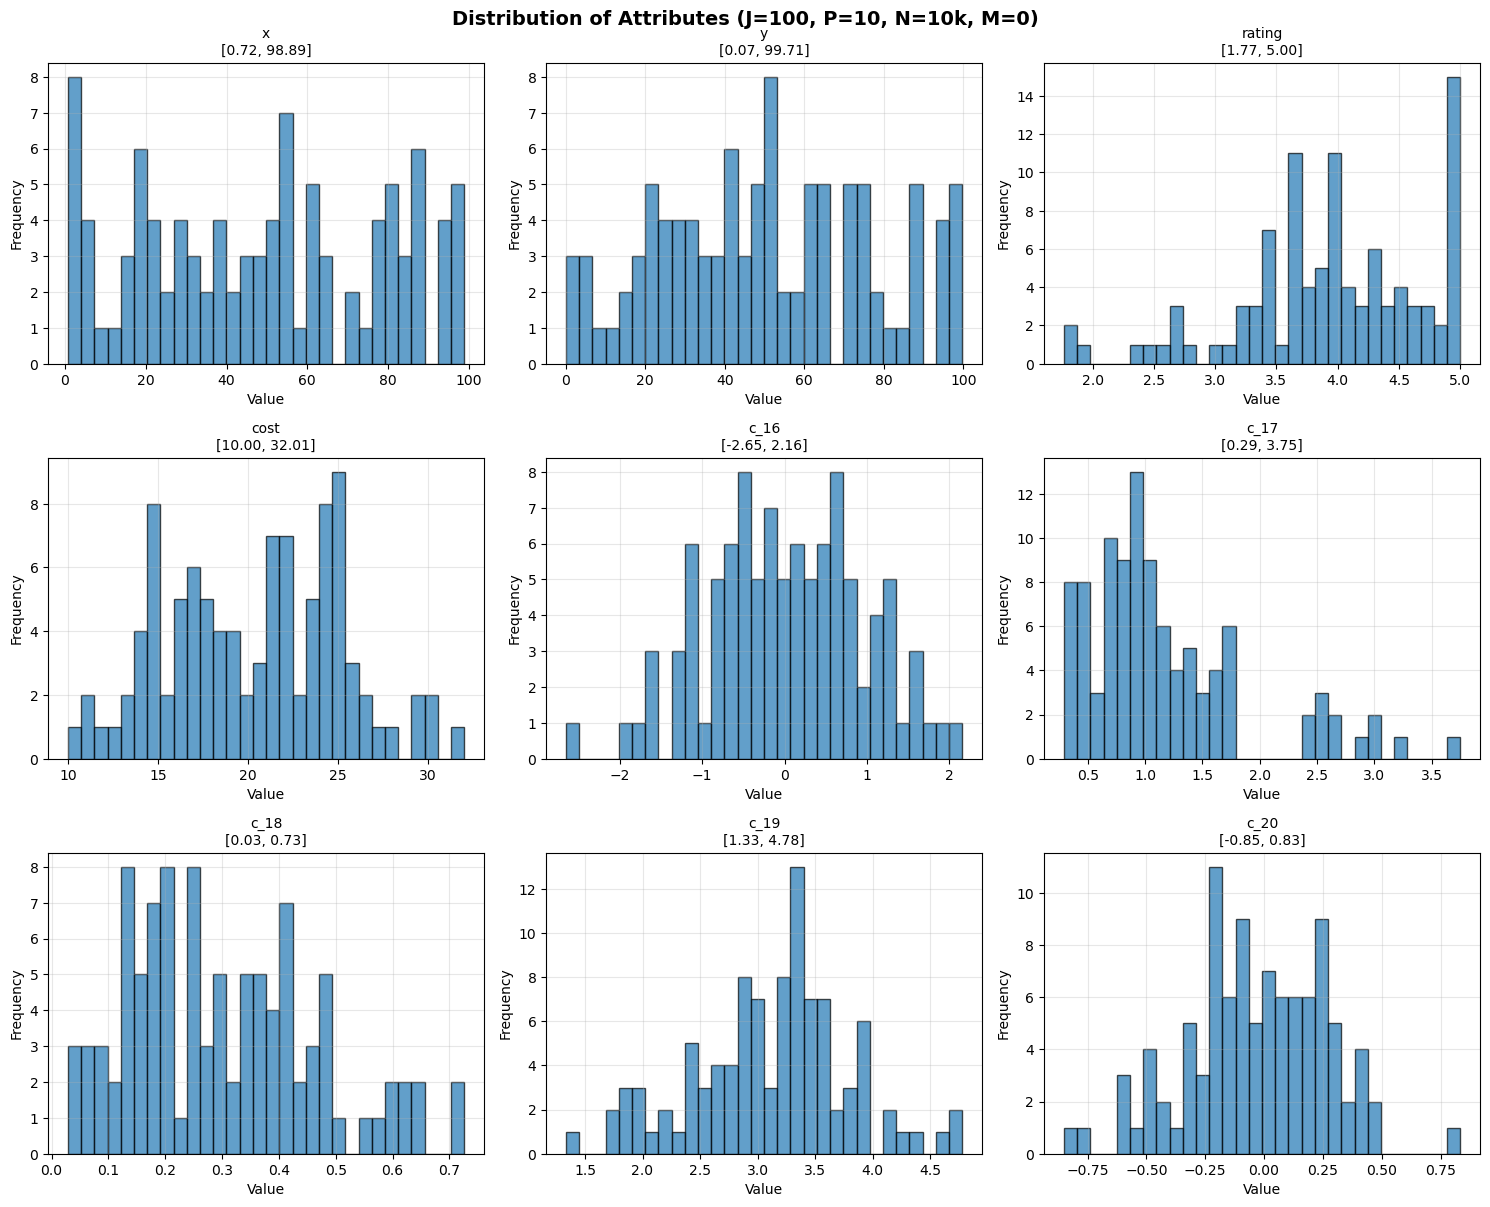


ℹ️  Showing first 9 attributes out of 39 total numeric attributes


In [19]:
if df_config is not None:
    # Visualize distributions
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()
    
    # Plot first 9 numeric attributes
    for idx, col in enumerate(numeric_cols[:9]):
        ax = axes[idx]
        ax.hist(df_config[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}\n[{df_config[col].min():.2f}, {df_config[col].max():.2f}]', 
                    fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numeric_cols[:9]), 9):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Distribution of Attributes (J={CONFIG_J}, P={CONFIG_P}, N={CONFIG_N}, M={CONFIG_M})', 
                 y=1.002, fontsize=14, fontweight='bold')
    plt.show()
    
    print(f"\nℹ️  Showing first 9 attributes out of {len(numeric_cols)} total numeric attributes")

## Step 8: Individual Attributes Scale Analysis (CHOICES)

Analyze the scale and distribution of individual-level attributes from the choices dataset.

In [20]:
# ==============================================================================
# CONFIG
# ==============================================================================
CHOICE_CONFIG_J = 100      # Alternatives: 100, 200, 500
CHOICE_CONFIG_P = 10       # Parameters: 10, 20, 40
CHOICE_CONFIG_N = '10k'    # Observations: '10k', '20k', '50k'
CHOICE_CONFIG_M = 0        # Choice randomness: 0 (selective), 1 (random)
# ==============================================================================

# Load the specific configuration for choices (individuals)
filename_choices = f"choices_J{CHOICE_CONFIG_J}_P{CHOICE_CONFIG_P}_N{CHOICE_CONFIG_N}_I0C0M{CHOICE_CONFIG_M}.csv"
filepath_choices = base_path / filename_choices

if filepath_choices.exists():
    df_choices = pd.read_csv(filepath_choices)
    print("="*80)
    print(f"INDIVIDUAL ATTRIBUTES SCALE ANALYSIS (CHOICES)")
    print(f"Configuration: J={CHOICE_CONFIG_J}, P={CHOICE_CONFIG_P}, N={CHOICE_CONFIG_N}, M={CHOICE_CONFIG_M}")
    print("="*80)
    print(f"\nDataset shape: {df_choices.shape}")
    print(f"Total columns: {len(df_choices.columns)}")
    print(f"Columns: {list(df_choices.columns)}")
else:
    print(f"❌ File not found: {filename_choices}")
    df_choices = None

INDIVIDUAL ATTRIBUTES SCALE ANALYSIS (CHOICES)
Configuration: J=100, P=10, N=10k, M=0

Dataset shape: (10000, 13)
Total columns: 13
Columns: ['individual_id', 'user_x', 'user_y', 'gender', 'age', 'edu_secondary', 'edu_tertiary', 'income_k', 'logincome', 'risk', 'has_children', 'logit_0', 'cuisine']


In [21]:
if df_choices is not None:
    # Identify numeric columns (exclude IDs, choice variables, and categorical)
    exclude_cols = ['individual_id', 'Unnamed: 0', 'logit_0']
    
    # Categorical/binary columns to exclude from numeric analysis
    categorical_cols = ['gender', 'married', 'employed', 'edu_secondary', 'edu_tertiary']
    
    numeric_cols_choices = [col for col in df_choices.columns 
                           if df_choices[col].dtype in ['float64', 'int64'] 
                           and col not in exclude_cols 
                           and col not in categorical_cols]
    
    print(f"\n{'='*80}")
    print(f"NUMERIC INDIVIDUAL ATTRIBUTES STATISTICS")
    print(f"{'='*80}\n")
    
    # Compute statistics for all numeric columns
    stats_data_choices = []
    for col in numeric_cols_choices:
        stats_data_choices.append({
            'Attribute': col,
            'Min': df_choices[col].min(),
            'Max': df_choices[col].max(),
            'Mean': df_choices[col].mean(),
            'Std': df_choices[col].std(),
            'Range': df_choices[col].max() - df_choices[col].min(),
            'Q25': df_choices[col].quantile(0.25),
            'Q75': df_choices[col].quantile(0.75)
        })
    
    stats_df_choices = pd.DataFrame(stats_data_choices)
    
    # Display with formatting
    pd.options.display.float_format = '{:.4f}'.format
    display(stats_df_choices)
    
    print(f"\n{'='*80}")
    print(f"SCALE COMPARISON")
    print(f"{'='*80}\n")
    
    # Group by scale magnitude
    print("Individual attributes grouped by order of magnitude:\n")
    
    for threshold, label in [(0.01, "Very Small (<0.01)"), 
                            (0.1, "Small (0.01-0.1)"),
                            (1, "Small-Medium (0.1-1)"),
                            (10, "Medium (1-10)"), 
                            (100, "Large (10-100)"),
                            (float('inf'), "Very Large (>100)")]:
        cols_in_range = stats_df_choices[(stats_df_choices['Range'] < threshold) & 
                                         (stats_df_choices['Range'] >= (0 if threshold == 0.01 else 
                                                                        0.01 if threshold == 0.1 else
                                                                        0.1 if threshold == 1 else
                                                                        1 if threshold == 10 else
                                                                        10 if threshold == 100 else 100))]
        if len(cols_in_range) > 0:
            print(f"\n{label}:")
            for _, row in cols_in_range.iterrows():
                print(f"  • {row['Attribute']:20s}: range [{row['Min']:.4f}, {row['Max']:.4f}], std={row['Std']:.4f}")
    
    print(f"\n{'='*80}")
    print(f"CATEGORICAL/BINARY INDIVIDUAL ATTRIBUTES")
    print(f"{'='*80}\n")
    
    for col in categorical_cols:
        if col in df_choices.columns:
            value_counts = df_choices[col].value_counts()
            print(f"{col}: {dict(value_counts)}")


NUMERIC INDIVIDUAL ATTRIBUTES STATISTICS



,Attribute,Min,Max,Mean,Std,Range,Q25,Q75
0,user_x,0.0489,99.9916,49.6449,28.8844,99.9427,24.4383,74.4559
1,user_y,0.0015,99.9978,50.2252,28.8731,99.9963,25.1053,75.2224
2,age,18.0000,80.0000,35.3790,11.2040,62.0000,26.8786,42.8981
3,income_k,10.0000,250.0000,68.1907,35.2901,240.0000,43.1559,84.8212
4,logincome,2.3026,5.5215,4.1009,0.4946,3.2189,3.7648,4.4405
5,risk,-3.0000,3.0000,0.0003,0.9942,6.0000,-0.6614,0.6786
6,has_children,0.0000,1.0000,0.3858,0.4868,1.0000,0.0000,1.0000



SCALE COMPARISON

Individual attributes grouped by order of magnitude:


Medium (1-10):
  • logincome           : range [2.3026, 5.5215], std=0.4946
  • risk                : range [-3.0000, 3.0000], std=0.9942
  • has_children        : range [0.0000, 1.0000], std=0.4868

Large (10-100):
  • user_x              : range [0.0489, 99.9916], std=28.8844
  • user_y              : range [0.0015, 99.9978], std=28.8731
  • age                 : range [18.0000, 80.0000], std=11.2040

Very Large (>100):
  • income_k            : range [10.0000, 250.0000], std=35.2901

CATEGORICAL/BINARY INDIVIDUAL ATTRIBUTES

gender: {1: np.int64(5025), 0: np.int64(4975)}
edu_secondary: {0: np.int64(6597), 1: np.int64(3403)}
edu_tertiary: {0: np.int64(7456), 1: np.int64(2544)}


In [22]:
if df_choices is not None:
    # Visual comparison of scales
    print(f"\n{'='*80}")
    print(f"NORMALIZATION RECOMMENDATION (INDIVIDUAL ATTRIBUTES)")
    print(f"{'='*80}\n")
    
    # Calculate scale ratios
    max_range_choices = stats_df_choices['Range'].max()
    min_range_choices = stats_df_choices[stats_df_choices['Range'] > 0]['Range'].min()
    scale_ratio_choices = max_range_choices / min_range_choices
    
    print(f"Largest range: {max_range_choices:.4f} ({stats_df_choices.loc[stats_df_choices['Range'].idxmax(), 'Attribute']})")
    print(f"Smallest range: {min_range_choices:.4f} ({stats_df_choices.loc[stats_df_choices['Range'].idxmin(), 'Attribute']})")
    print(f"Scale ratio (max/min): {scale_ratio_choices:.2f}x")
    
    print("\n" + "="*80)
    if scale_ratio_choices > 100:
        print("⚠️  STRONG RECOMMENDATION: Normalize the data")
        print("   Individual attributes span more than 2 orders of magnitude")
    elif scale_ratio_choices > 10:
        print("⚠️  RECOMMENDATION: Consider normalizing the data")
        print("   Individual attributes span more than 1 order of magnitude")
    else:
        print("✓  OPTIONAL: Normalization may not be critical")
        print("   Individual attributes are on relatively similar scales")
    print("="*80)
    
    # Show which attributes are outliers in terms of scale
    mean_range_choices = stats_df_choices['Range'].mean()
    std_range_choices = stats_df_choices['Range'].std()
    
    outlier_threshold_choices = mean_range_choices + 2 * std_range_choices
    outliers_choices = stats_df_choices[stats_df_choices['Range'] > outlier_threshold_choices]
    
    if len(outliers_choices) > 0:
        print(f"\n⚠️  Individual attributes with unusually large scales (>2σ from mean):")
        for _, row in outliers_choices.iterrows():
            print(f"   • {row['Attribute']}: range = {row['Range']:.4f}")


NORMALIZATION RECOMMENDATION (INDIVIDUAL ATTRIBUTES)

Largest range: 240.0000 (income_k)
Smallest range: 1.0000 (has_children)
Scale ratio (max/min): 240.00x

⚠️  STRONG RECOMMENDATION: Normalize the data
   Individual attributes span more than 2 orders of magnitude


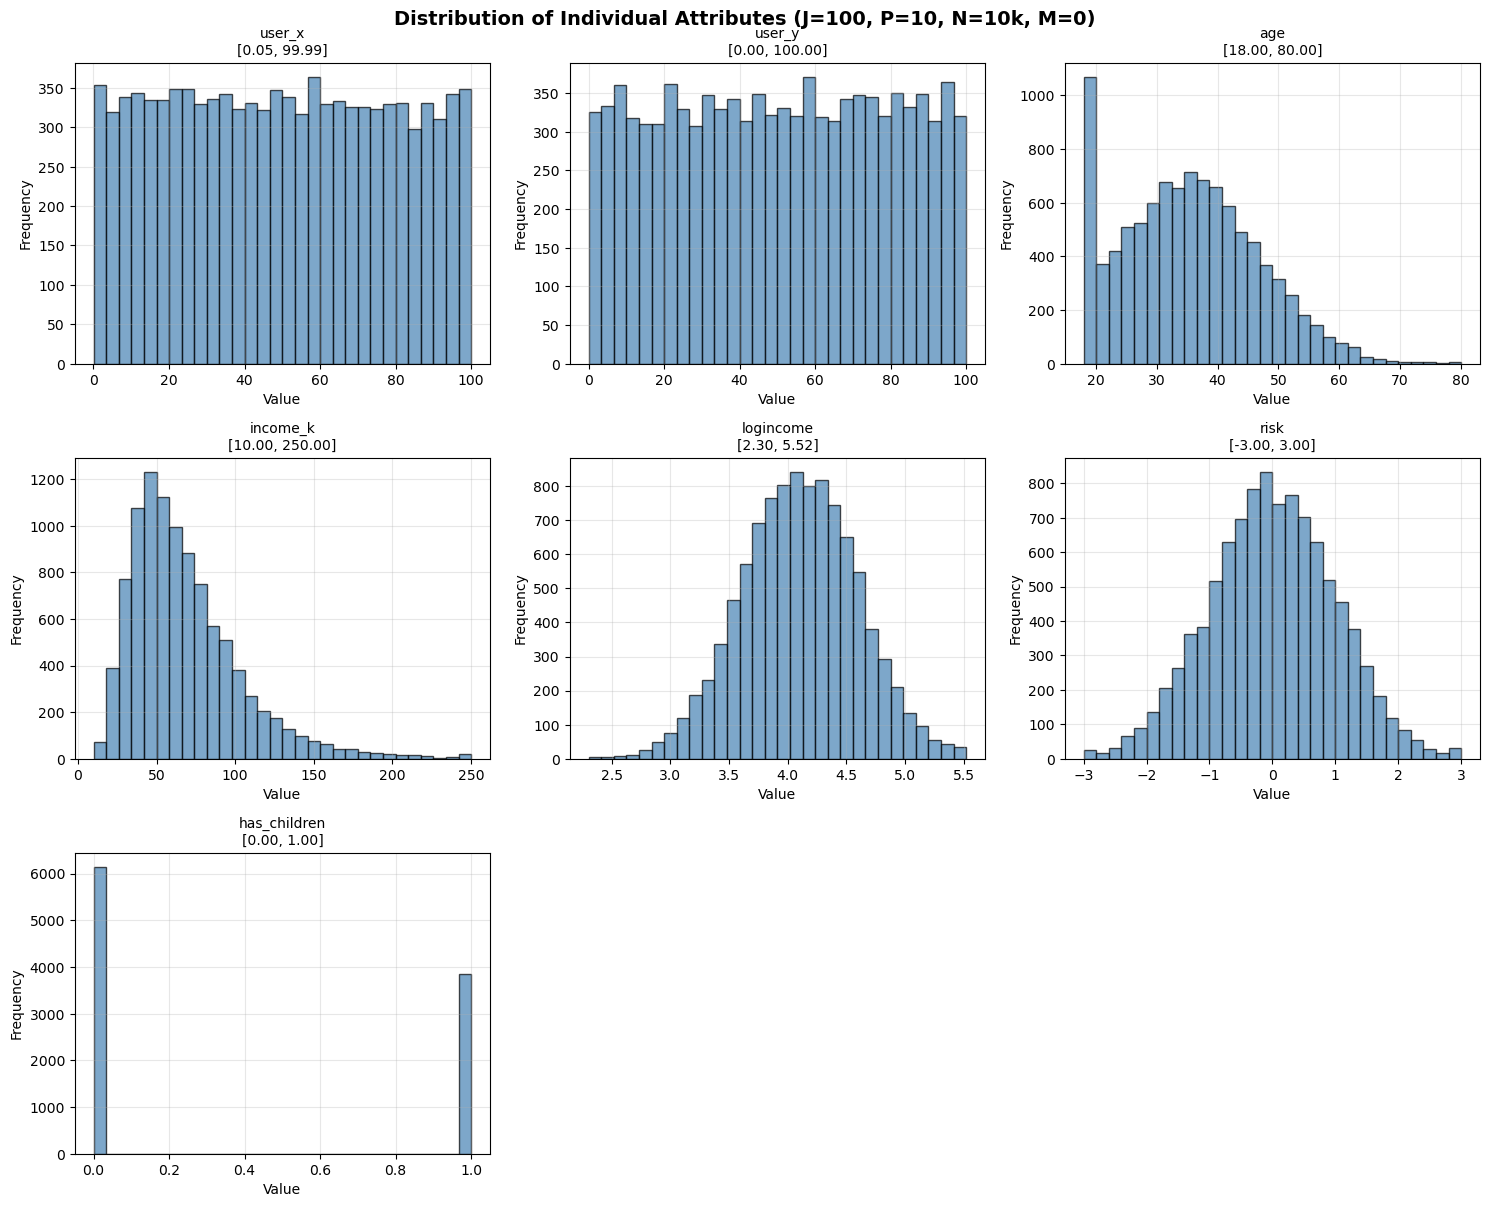


ℹ️  Showing first 7 attributes out of 7 total numeric individual attributes


In [23]:
if df_choices is not None and len(numeric_cols_choices) > 0:
    # Visualize distributions of individual attributes
    n_plots = min(len(numeric_cols_choices), 9)
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()
    
    # Plot individual attributes
    for idx, col in enumerate(numeric_cols_choices[:n_plots]):
        ax = axes[idx]
        ax.hist(df_choices[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'{col}\n[{df_choices[col].min():.2f}, {df_choices[col].max():.2f}]', 
                    fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_plots, 9):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Distribution of Individual Attributes (J={CHOICE_CONFIG_J}, P={CHOICE_CONFIG_P}, N={CHOICE_CONFIG_N}, M={CHOICE_CONFIG_M})', 
                 y=1.002, fontsize=14, fontweight='bold')
    plt.show()
    
    print(f"\nℹ️  Showing first {n_plots} attributes out of {len(numeric_cols_choices)} total numeric individual attributes")

In [24]:
if df_choices is not None and df_config is not None:
    # Combined comparison of restaurant and individual attribute scales
    print("\n" + "="*80)
    print("COMBINED SCALE COMPARISON: RESTAURANT vs INDIVIDUAL ATTRIBUTES")
    print("="*80)
    print(f"\nRestaurant attributes (J={CONFIG_J}, P={CONFIG_P}):")
    print(f"  • Number of numeric attributes: {len(stats_df)}")
    print(f"  • Scale range: {stats_df['Range'].min():.4f} to {stats_df['Range'].max():.4f}")
    print(f"  • Scale ratio: {stats_df['Range'].max() / stats_df[stats_df['Range'] > 0]['Range'].min():.2f}x")
    
    print(f"\nIndividual attributes (N={CHOICE_CONFIG_N}):")
    print(f"  • Number of numeric attributes: {len(stats_df_choices)}")
    print(f"  • Scale range: {stats_df_choices['Range'].min():.4f} to {stats_df_choices['Range'].max():.4f}")
    print(f"  • Scale ratio: {stats_df_choices['Range'].max() / stats_df_choices[stats_df_choices['Range'] > 0]['Range'].min():.2f}x")
    
    # Combined scale ratio
    all_ranges = pd.concat([stats_df['Range'], stats_df_choices['Range']])
    combined_max = all_ranges.max()
    combined_min = all_ranges[all_ranges > 0].min()
    combined_ratio = combined_max / combined_min
    
    print(f"\nCombined (all attributes):")
    print(f"  • Total numeric attributes: {len(stats_df) + len(stats_df_choices)}")
    print(f"  • Combined scale ratio: {combined_ratio:.2f}x")
    
    print("\n" + "="*80)
    if combined_ratio > 100:
        print("⚠️  STRONG RECOMMENDATION: Normalize ALL data (restaurant + individual)")
        print("   Combined attributes span more than 2 orders of magnitude")
    elif combined_ratio > 10:
        print("⚠️  RECOMMENDATION: Consider normalizing ALL data")
        print("   Combined attributes span more than 1 order of magnitude")
    else:
        print("✓  OPTIONAL: Normalization may not be critical")
        print("   Combined attributes are on relatively similar scales")
    print("="*80)


COMBINED SCALE COMPARISON: RESTAURANT vs INDIVIDUAL ATTRIBUTES

Restaurant attributes (J=100, P=10):
  • Number of numeric attributes: 39
  • Scale range: 0.5663 to 99.6375
  • Scale ratio: 175.94x

Individual attributes (N=10k):
  • Number of numeric attributes: 7
  • Scale range: 1.0000 to 240.0000
  • Scale ratio: 240.00x

Combined (all attributes):
  • Total numeric attributes: 46
  • Combined scale ratio: 423.79x

⚠️  STRONG RECOMMENDATION: Normalize ALL data (restaurant + individual)
   Combined attributes span more than 2 orders of magnitude
